In [1]:
## Cell 1 — Config & Load
import json
import re
import os
import statistics
from pathlib import Path
from collections import Counter, defaultdict

RESULTS_DIR = Path.cwd().parent / "data" / "results"

# ── Set to None for newest run, or specify filename ──
RUN_FILE = "run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_181527.jsonl"
# RUN_FILE = "run_fin_no_rerank_20260326_224126.jsonl"

# ── Auto-select newest JSONL if not set ──
if RUN_FILE is None:
    jsonl_files = sorted(RESULTS_DIR.glob("run_fin_*.jsonl"), key=lambda p: p.stat().st_mtime)
    # skip tiny files (< 10 lines)
    jsonl_files = [f for f in jsonl_files if f.stat().st_size > 5000]
    if not jsonl_files:
        raise FileNotFoundError(f"No JSONL files found in {RESULTS_DIR}")
    RUN_FILE = jsonl_files[-1].name
    print(f"Auto-selected newest run: {RUN_FILE}")

run_path = RESULTS_DIR / RUN_FILE
run_name = Path(RUN_FILE).stem

# ── Load JSONL (skip non-JSON prefix bytes) ──
results = []
with open(run_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        # Find first '{' to skip any garbage prefix
        idx = line.find("{")
        if idx >= 0:
            results.append(json.loads(line[idx:]))

# ── Merge context_pages & llm_answer from .json sidecar ──
json_path = RESULTS_DIR / (run_name + ".json")
if json_path.exists():
    with open(json_path, encoding="utf-8") as f:
        json_data = json.load(f)
    print(f"Loaded .json sidecar: {json_path.name} ({len(json_data)} records)")

    for r_jsonl, r_json in zip(results, json_data):
        # Merge context pages
        if "context_pages" in r_json:
            r_jsonl["context_pages"] = r_json["context_pages"]
        # Merge llm_answer (contains <think> tags)
        if "llm_answer" in r_json and "llm_answer" not in r_jsonl:
            r_jsonl["llm_answer"] = r_json["llm_answer"]
        # Extract think_text from llm_answer if missing
        if r_jsonl.get("think_text") is None and "llm_answer" in r_jsonl:
            llm = r_jsonl["llm_answer"]
            t_start = llm.find("<think>")
            t_end = llm.find("</think>")
            if t_start >= 0 and t_end > t_start:
                r_jsonl["think_text"] = llm[t_start + 7 : t_end]
        # Merge PoT pipeline fields from sidecar (authoritative for generated_code)
        for pot_field in ("fact_thinking", "code_thinking", "generated_code",
                          "code_output", "extracted_facts", "execution_error",
                          "retry_count"):
            if pot_field in r_json and not r_jsonl.get(pot_field):
                r_jsonl[pot_field] = r_json[pot_field]

    # ── Detect pipeline type ──
    is_pot = any(r.get("fact_thinking") or r.get("code_thinking") for r in results)

    n_with_pages = sum(1 for r in results if "context_pages" in r)
    print(f"  Merged context_pages: {n_with_pages}/{len(results)}")
    if is_pot:
        n_with_code = sum(1 for r in results if r.get("generated_code"))
        n_with_exec_err = sum(1 for r in results if r.get("execution_error"))
        n_with_retry = sum(1 for r in results if r.get("retry_count", 0) > 0)
        print(f"  Pipeline: PoT (2-step)")
        print(f"  Records with generated_code: {n_with_code}/{len(results)}")
        print(f"  Records with execution_error: {n_with_exec_err}/{len(results)}")
        print(f"  Records with retry: {n_with_retry}/{len(results)}")
    else:
        n_with_think = sum(1 for r in results if r.get("think_text"))
        print(f"  Pipeline: Direct (think tags)")
        print(f"  Records with think_text: {n_with_think}/{len(results)}")
else:
    is_pot = any(r.get("fact_thinking") or r.get("code_thinking") for r in results)
    print(f"WARNING: No .json sidecar found at {json_path}")
    print(f"  Context pages will NOT be available in error report")
    if is_pot:
        print(f"  NOTE: PoT fields from JSONL only (generated_code may be incomplete)")

# ── Stats ──
n_total = len(results)
n_exact = sum(1 for r in results if r["exact_match"])
n_lenient = sum(1 for r in results if r["lenient_match"])
n_ret = sum(1 for r in results if r["retrieval_hit"])

methods = set(r.get("retrieval_method", "?") for r in results)
models = set(r.get("model", "?") for r in results)
top_pages = set(r.get("top_pages", "?") for r in results)

print(f"\n{'='*60}")
print(f"  Run:       {run_name}")
print(f"  Model:     {', '.join(str(m) for m in models)}")
print(f"  Retrieval: {', '.join(str(m) for m in methods)}")
print(f"  Top pages: {', '.join(str(t) for t in top_pages)}")
print(f"  Questions: {n_total}")
print(f"{'='*60}")
print(f"  Exact match:    {n_exact:>4}/{n_total} = {n_exact/n_total*100:.1f}%")
print(f"  Lenient match:  {n_lenient:>4}/{n_total} = {n_lenient/n_total*100:.1f}%  <-- primary")
print(f"  Retrieval hit:  {n_ret:>4}/{n_total} = {n_ret/n_total*100:.1f}%")

# ── Filter to errors (retrieval hit but wrong answer) ──
errors = [r for r in results if r["retrieval_hit"] and not r["lenient_match"]]
no_retrieval = [r for r in results if not r["retrieval_hit"]]

print(f"\n  Errors to analyze:     {len(errors)} (retrieval hit, wrong answer)")
print(f"  Retrieval misses:      {len(no_retrieval)} (GT page not retrieved)")
print(f"  Correct answers:       {n_lenient}")

  Context pages will NOT be available in error report
  NOTE: PoT fields from JSONL only (generated_code may be incomplete)

  Run:       run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_181527
  Model:     google/gemma-4-26b-a4b
  Retrieval: rrf_4way_2step_pot
  Top pages: 10
  Questions: 186
  Exact match:      45/186 = 24.2%
  Lenient match:    93/186 = 50.0%  <-- primary
  Retrieval hit:   170/186 = 91.4%

  Errors to analyze:     79 (retrieval hit, wrong answer)
  Retrieval misses:      16 (GT page not retrieved)
  Correct answers:       93


In [2]:
## Cell 2 — Helpers

def normalize_answer(val: str) -> str:
    s = str(val).strip().lower()
    s = s.replace(",", "").replace("%", "").replace("$", "").replace(" ", "")
    if s.endswith(".0"):
        s = s[:-2]
    return s

def try_float(val: str):
    try:
        return float(normalize_answer(val))
    except (ValueError, TypeError):
        return None

def extract_answer(r):
    """Extract display answer (after </think>)."""
    # Prefer display_answer from JSONL (already extracted)
    if r.get("display_answer"):
        return str(r["display_answer"]).strip()
    llm = r.get("llm_answer", "")
    if "</think>" in llm:
        return llm.split("</think>")[-1].strip()
    return llm.strip()

def gt_page_rank(r):
    """Position of GT page in selected_pages (1-based), or None."""
    pages = r.get("selected_pages", r.get("retrieved_pages", []))
    gt = r.get("gt_page")
    if gt is not None and gt in pages:
        return pages.index(gt) + 1
    return None

def gt_in_prompt(r):
    """Check if any GT answer value appears literally in the context pages."""
    # Build searchable text from context pages (merged from .json)
    pages = r.get("context_pages", [])
    if pages:
        prompt = " ".join(p.get("text", "") for p in pages)
    else:
        prompt = r.get("prompt", "")

    if not prompt:
        return False

    for gt in r.get("gt_answers", []):
        gt_clean = normalize_answer(gt)
        gt_f = try_float(gt)
        # Check raw string
        if gt_clean in prompt.lower().replace(",", "").replace("%", "").replace("$", ""):
            return True
        # Check float formatted various ways
        if gt_f is not None:
            for fmt in [f"{gt_f}", f"{gt_f:.1f}", f"{gt_f:.2f}", f"{gt_f:,.0f}", f"{gt_f:,.1f}"]:
                if fmt in prompt:
                    return True
    return False

print("Helpers loaded")

Helpers loaded


In [3]:
## Cell 3 — Automatic Error Categorization

import pandas as pd

# Median completion tokens (for OVERTHINKING threshold)
all_comp_tokens = [r.get("completion_tokens", 0) for r in results if r.get("completion_tokens")]
median_comp = statistics.median(all_comp_tokens) if all_comp_tokens else 500

def categorize_error(r):
    """Assign error categories based on heuristics. Returns list of category strings."""
    cats = []

    # ── PoT-specific: code execution failure ──
    if r.get("execution_error"):
        cats.append("CODE_ERROR")

    # ── PoT-specific: had to retry code generation ──
    if r.get("retry_count", 0) > 0:
        cats.append("RETRY")

    llm_answer = extract_answer(r)
    gt_answers = r.get("gt_answers", [])

    llm_f = try_float(llm_answer)
    gt_floats = [try_float(g) for g in gt_answers]
    gt_floats = [g for g in gt_floats if g is not None]

    # ── NON_NUMERIC: LLM didn't return a number ──
    if llm_f is None:
        if "insufficient" in llm_answer.lower():
            cats.append("INSUFFICIENT")
        else:
            cats.append("NON_NUMERIC")
    elif gt_floats:
        gt_f = gt_floats[0]

        # ── SIGN_ERROR: same magnitude, different sign ──
        if gt_f != 0 and llm_f != 0:
            if abs(abs(llm_f) - abs(gt_f)) / abs(gt_f) <= 0.02 and (llm_f * gt_f < 0):
                cats.append("SIGN_ERROR")

        # ── UNIT_ERROR: off by factor of 10/100/1000 ──
        if gt_f != 0:
            ratio = llm_f / gt_f if gt_f != 0 else None
            if ratio is not None:
                for factor in [10, 100, 1000, 0.1, 0.01, 0.001]:
                    if abs(ratio - factor) / factor < 0.05:
                        cats.append("UNIT_ERROR")
                        break

        # ── ROUNDING: close but outside lenient threshold (1%), within 5% ──
        if gt_f != 0:
            rel_err = abs(llm_f - gt_f) / abs(gt_f)
            if 0.01 < rel_err <= 0.05:
                cats.append("ROUNDING")

    # ── GT_IN_PROMPT vs CALC_REQUIRED ──
    if gt_in_prompt(r):
        cats.append("GT_IN_PROMPT")
    else:
        cats.append("CALC_REQUIRED")

    # ── OVERTHINKING: way more tokens than typical ──
    comp = r.get("completion_tokens", 0)
    if comp > 2 * median_comp:
        cats.append("OVERTHINKING")

    # ── GT_PAGE_LOW_RANK ──
    rank = gt_page_rank(r)
    if rank is not None and rank >= 5:
        cats.append("GT_PAGE_LOW_RANK")

    # Fallback if no specific error pattern found
    if not cats or cats == ["CALC_REQUIRED"] or cats == ["GT_IN_PROMPT"]:
        if llm_f is not None and gt_floats:
            cats.append("WRONG_CALCULATION")

    return cats

# ── Categorize all errors ──
error_records = []
for r in errors:
    cats = categorize_error(r)
    rank = gt_page_rank(r)
    error_records.append({
        "q_uid": r["q_uid"],
        "doc_name": r["doc_name"],
        "question": r["question"],
        "gt": r["gt_answers"],
        "llm_answer": extract_answer(r),
        "categories": cats,
        "comp_tokens": r.get("completion_tokens", 0),
        "gt_page_rank": rank,
        "gt_page": r.get("gt_page"),
    })

error_df = pd.DataFrame(error_records)

# ── Category frequency ──
cat_counts = Counter()
for cats in error_df["categories"]:
    for c in cats:
        cat_counts[c] += 1

print(f"Categorized {len(error_df)} errors:\n")
print(f"  {'Category':<20} {'Count':>5} {'%':>6}")
print(f"  {'-'*35}")
for cat, count in cat_counts.most_common():
    print(f"  {cat:<20} {count:>5} {count/len(error_df)*100:>5.1f}%")

print(f"\n  Median completion tokens (all answers): {median_comp:.0f}")
print(f"  Overthinking threshold: >{2*median_comp:.0f} tokens")

Categorized 79 errors:

  Category             Count      %
  -----------------------------------
  GT_IN_PROMPT            64  81.0%
  OVERTHINKING            33  41.8%
  GT_PAGE_LOW_RANK        21  26.6%
  INSUFFICIENT            20  25.3%
  CALC_REQUIRED           15  19.0%
  WRONG_CALCULATION       13  16.5%
  ROUNDING                10  12.7%
  SIGN_ERROR               3   3.8%
  UNIT_ERROR               1   1.3%

  Median completion tokens (all answers): 540
  Overthinking threshold: >1080 tokens


C:\Users\phili\AppData\Local\Temp\ipykernel_29280\2424550549.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct_comp, wrong_comp], labels=["Correct", "Wrong"], patch_artist=True)


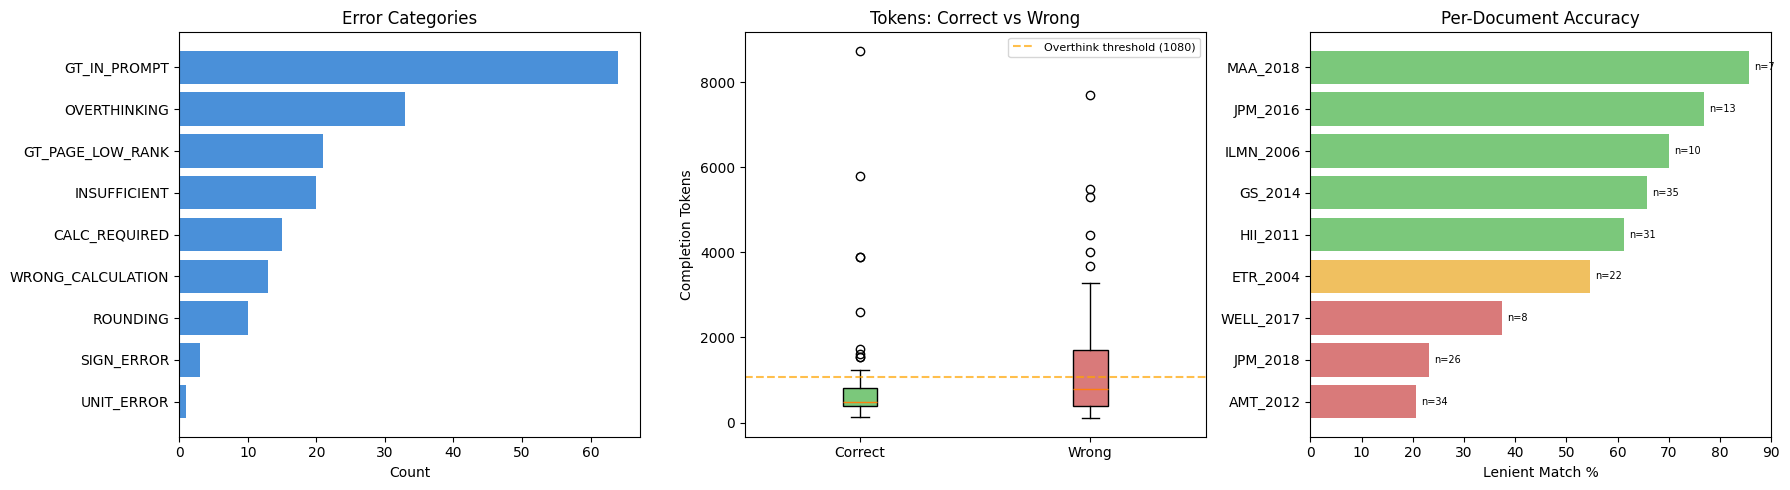

In [4]:
## Cell 4 — Visualizations

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Category frequency bar chart ──
cats_sorted = cat_counts.most_common()
ax = axes[0]
ax.barh([c[0] for c in cats_sorted], [c[1] for c in cats_sorted], color="#4a90d9")
ax.set_xlabel("Count")
ax.set_title("Error Categories")
ax.invert_yaxis()

# ── 2. Completion tokens: correct vs wrong ──
correct_comp = [r.get("completion_tokens", 0) for r in results if r["lenient_match"] and r.get("completion_tokens")]
wrong_comp = [r.get("completion_tokens", 0) for r in errors if r.get("completion_tokens")]

ax = axes[1]
bp = ax.boxplot([correct_comp, wrong_comp], labels=["Correct", "Wrong"], patch_artist=True)
bp["boxes"][0].set_facecolor("#7bc87b")
bp["boxes"][1].set_facecolor("#d97a7a")
ax.set_ylabel("Completion Tokens")
ax.set_title("Tokens: Correct vs Wrong")
ax.axhline(y=2*median_comp, color="orange", linestyle="--", alpha=0.7, label=f"Overthink threshold ({2*median_comp:.0f})")
ax.legend(fontsize=8)

# ── 3. Per-document error rate ──
doc_total = Counter(r["doc_name"] for r in results)
doc_lenient = Counter(r["doc_name"] for r in results if r["lenient_match"])
doc_data = []
for doc in sorted(doc_total.keys()):
    n = doc_total[doc]
    le = doc_lenient.get(doc, 0)
    doc_data.append((doc, le / n * 100, n))

doc_data.sort(key=lambda x: x[1])
ax = axes[2]
colors = ["#d97a7a" if d[1] < 40 else "#f0c060" if d[1] < 60 else "#7bc87b" for d in doc_data]
ax.barh([d[0] for d in doc_data], [d[1] for d in doc_data], color=colors)
ax.set_xlabel("Lenient Match %")
ax.set_title("Per-Document Accuracy")
for i, (doc, pct, n) in enumerate(doc_data):
    ax.text(pct + 1, i, f"n={n}", va="center", fontsize=7)

plt.tight_layout()
plt.show()


In [5]:
## Cell 5 — Generate Error Report for LLM Analysis

# ── Report mode ──
# "full"    = complete think text + context pages (for detailed analysis)
# "compact" = truncated think, no pages (~20k tokens, fits in Claude.ai)
REPORT_MODE = "full"

THINK_CHARS = 300  # only used in compact mode


def build_error_block(r, idx, mode="full"):
    """Build an error block for one question."""
    cats = categorize_error(r)
    llm_answer = extract_answer(r)
    rank = gt_page_rank(r)
    context_pages = r.get("context_pages", [])
    gt_page = r.get("gt_page")

    # Detect if this record is from a PoT run
    record_is_pot = bool(r.get("fact_thinking") or r.get("code_thinking"))

    lines = [
        f"### Error {idx}: {r['doc_name']} | {', '.join(cats)}",
        f"Q: {r['question']}",
        f"GT: {r['gt_answers'][0] if r['gt_answers'] else '?'} | LLM: {llm_answer[:80]} | tokens: {r.get('completion_tokens', '?')} | gt_page_rank: {rank}",
    ]

    if record_is_pot:
        # ── PoT pipeline: show full reasoning chain ──
        fact_thinking = r.get("fact_thinking") or ""
        extracted_facts = r.get("extracted_facts") or ""
        code_thinking = r.get("code_thinking") or ""
        generated_code = r.get("generated_code") or "(no code extracted)"
        code_output = r.get("code_output") or ""
        exec_error = r.get("execution_error") or ""
        retry_count = r.get("retry_count", 0)

        if mode == "full":
            lines.append(f"\n**Fact Thinking (Step 1):**\n{fact_thinking}\n")
            lines.append(f"\n**Extracted Facts:**\n{extracted_facts}\n")
            lines.append(f"\n**Code Thinking (Step 2):**\n{code_thinking}\n")
            lines.append(f"\n**Generated Code:**\n```python\n{generated_code}\n```\n")
            lines.append(f"\n**Code Output:** {code_output}")
            if exec_error:
                lines.append(f"\n**Execution Error:** {exec_error}")
            if retry_count > 0:
                lines.append(f"\n**Retry Count:** {retry_count}")
        else:
            # Compact mode: truncate thinking, show facts and code in full
            fact_think_trunc = fact_thinking[:THINK_CHARS].replace("\n", " ") if fact_thinking else "(none)"
            code_think_trunc = code_thinking[:THINK_CHARS].replace("\n", " ") if code_thinking else "(none)"
            lines.append(f"Fact thinking: {fact_think_trunc}")
            lines.append(f"Extracted facts: {extracted_facts}")
            lines.append(f"Code thinking: {code_think_trunc}")
            lines.append(f"Code: {generated_code}")
            lines.append(f"Code output: {code_output}")
            if exec_error:
                lines.append(f"Exec error: {exec_error}")
            if retry_count > 0:
                lines.append(f"Retry: {retry_count}")
    else:
        # ── Legacy pipeline: show think_text ──
        think = r.get("think_text", "") or ""
        if mode == "full":
            lines.append(f"\n**Think text:**\n{think}\n")
        else:
            think_start = think[:THINK_CHARS].replace("\n", " ") if think else "(no think text)"
            think_end = think[-THINK_CHARS:].replace("\n", " ") if len(think) > THINK_CHARS else ""
            lines.append(f"Think start: {think_start}")
            if think_end:
                lines.append(f"Think end: ...{think_end}")

    # ── Context pages (same for both pipelines) ──
    if mode == "full":
        if context_pages:
            lines.append(f"\n**Context Pages ({len(context_pages)} pages, GT page = {gt_page}):**\n")
            for cp in context_pages:
                page_num = cp.get("page", "?")
                text = cp.get("text", "")
                marker = " <<<< GT PAGE" if page_num == gt_page else ""
                lines.append(f"--- Page {page_num}{marker} ---")
                lines.append(text)
                lines.append("")
        lines.append("")

    lines.append("")
    return "\n".join(lines)


# ── Build full report ──
report_lines = []

# Header
report_lines.append(f"# Error Analysis Report: {run_name}\n")
pipeline_type = "PoT (2-step)" if is_pot else "Direct"
report_lines.append(f"Model: {', '.join(str(m) for m in models)} | Method: {', '.join(str(m) for m in methods)} | Top pages: {', '.join(str(t) for t in top_pages)} | Pipeline: {pipeline_type}")
report_lines.append(f"Total: {n_total} questions | Lenient: {n_lenient}/{n_total} ({n_lenient/n_total*100:.1f}%) | Retrieval: {n_ret}/{n_total} ({n_ret/n_total*100:.1f}%)")
report_lines.append(f"Errors analyzed: {len(errors)} (retrieval hit but wrong answer)")
report_lines.append(f"Report mode: {REPORT_MODE}\n")

# Category summary
report_lines.append("## Error Category Distribution\n")
for cat, count in cat_counts.most_common():
    report_lines.append(f"- **{cat}**: {count} ({count/len(errors)*100:.0f}%)")
report_lines.append("")

# Category explanations
report_lines.append("Categories: CALC_REQUIRED=GT not in prompt (must calculate), GT_IN_PROMPT=GT in prompt (model missed it), "
                     "WRONG_CALCULATION=numeric error, OVERTHINKING=2x median tokens, UNIT_ERROR=off by 10/100/1000x, "
                     "SIGN_ERROR=wrong sign, ROUNDING=within 5% but outside 1%, INSUFFICIENT=said insufficient context, "
                     "NON_NUMERIC=non-numeric response, GT_PAGE_LOW_RANK=GT page ranked 5+, "
                     "CODE_ERROR=code execution failed, RETRY=code generation was retried\n")

# Individual errors
report_lines.append("## Individual Errors\n")
for idx, r in enumerate(errors, 1):
    report_lines.append(build_error_block(r, idx, mode=REPORT_MODE))

report_text = "\n".join(report_lines)

# ── Save report ──
report_path = RESULTS_DIR / f"{run_name}_error_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Report saved: {report_path}")
print(f"Report size:  {len(report_text):,} chars (~{len(report_text)//4:,} tokens)")
print(f"Report mode:  {REPORT_MODE}")

if REPORT_MODE == "full":
    print(f"\nFull report is too large for Claude.ai in one paste.")
    print(f"Use REPORT_MODE = 'compact' for a ~20k token version.")
elif REPORT_MODE == "compact":
    print(f"\nYou can paste this into Claude.ai or Claude Code for LLM analysis.")

print(f"\n{'='*60}")
print(f"  PREVIEW (first 2 errors)")
print(f"{'='*60}")
for idx, r in enumerate(errors[:2], 1):
    preview = build_error_block(r, idx, mode=REPORT_MODE)
    # In full mode, truncate preview for display
    if REPORT_MODE == "full" and len(preview) > 2000:
        preview = preview[:2000] + "\n  [...truncated in preview...]\n"
    print(preview)

Report saved: C:\Users\phili\PycharmProjects\Retrieval_Program_of_Thought\data\results\run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_181527_error_report.md
Report size:  5,226,013 chars (~1,306,503 tokens)
Report mode:  full

Full report is too large for Claude.ai in one paste.
Use REPORT_MODE = 'compact' for a ~20k token version.

  PREVIEW (first 2 errors)
### Error 1: AMT_2012 | INSUFFICIENT, GT_IN_PROMPT, OVERTHINKING, GT_PAGE_LOW_RANK
Q: for acquired customer-related and network location intangibles , what is the expected annual amortization expenses , in millions?
GT: 7.4 | LLM: INSUFFICIENT CONTEXT | tokens: 2920 | gt_page_rank: 9

**Fact Thinking (Step 1):**

*   Target information: Expected annual amortization expenses for "acquired customer-related" and "network location" intangibles.
    *   Unit requested: Millions.
    *   Constraint: Extract raw values from context, do not compute.

    *   Page 1 mentions: "Amortization of intangible assets for the years ended Decembe

In [6]:
## Cell 6 — Optional: Claude API Analysis

# Set your API key here or via environment variable
ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")
ANALYZE_WITH_API = False   # flip to True to send report to Claude
CLAUDE_MODEL = "claude-sonnet-4-20250514"

META_PROMPT = """You are an expert evaluator for a Financial QA RAG system.
Below is an error report from a 2-step Program of Thought (PoT) pipeline that:
1. Retrieves pages from SEC 10-K annual reports
2. Step 1: Extracts numerical facts from retrieved pages
3. Step 2: Generates Python code to compute the answer from extracted facts
4. Executes the code and uses its output as the final answer

Your task:
1. Identify the TOP 5 most common error patterns with concrete examples
2. For each pattern, explain WHERE in the pipeline the failure occurs (fact extraction, code logic, code execution, or retrieval)
3. Suggest specific improvements to prompts, fact extraction, or code generation
4. Estimate how many of the errors each fix would address

Focus on actionable changes to the system prompt or user prompt format.
Be specific — quote the current prompt rules that are insufficient and suggest exact rewording.

The current system prompt rules are:
- Pages ranked by relevance, use highest-ranked on conflicts
- Return ONLY the answer, no units/symbols
- Numbers: raw numeric value. Percentages: 1 decimal
- "By how much did X change" → percentage change
- "Total" means sum. "Average per year" means divide by number of years
- Only say INSUFFICIENT CONTEXT if metric genuinely absent from ALL pages
"""

if ANALYZE_WITH_API and ANTHROPIC_API_KEY:
    try:
        import anthropic
    except ImportError:
        print("Install anthropic: pip install anthropic")
        raise

    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    # Truncate report if too large (keep header + first 60 errors)
    if len(report_text) > 80_000:
        # Find the 60th error marker
        marker = "### Error 61:"
        cut_pos = report_text.find(marker)
        if cut_pos > 0:
            send_text = report_text[:cut_pos] + f"\n\n[... truncated, {len(errors)-60} more errors ...]\n"
        else:
            send_text = report_text[:80_000]
        print(f"Report truncated from {len(report_text):,} to {len(send_text):,} chars for API call")
    else:
        send_text = report_text

    print(f"Sending ~{len(send_text)//4:,} tokens to {CLAUDE_MODEL}...")
    response = client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=4096,
        messages=[
            {"role": "user", "content": f"{META_PROMPT}\n\n---\n\n{send_text}"}
        ],
    )
    analysis = response.content[0].text
    print("\n" + "="*60)
    print("  CLAUDE ANALYSIS")
    print("="*60)
    print(analysis)

    # Save analysis
    analysis_path = RESULTS_DIR / f"{run_name}_llm_analysis.md"
    with open(analysis_path, "w", encoding="utf-8") as f:
        f.write(f"# LLM Analysis: {run_name}\n\nModel: {CLAUDE_MODEL}\n\n{analysis}")
    print(f"\nSaved to: {analysis_path}")
else:
    print("Claude API analysis is disabled.")
    print(f"To use it: set ANTHROPIC_API_KEY and ANALYZE_WITH_API = True")
    print(f"\nAlternatively, paste the error report into Claude.ai or Claude Code:")
    print(f"  {report_path}")
    print(f"  ({len(report_text):,} chars / ~{len(report_text)//4:,} tokens)")

Claude API analysis is disabled.
To use it: set ANTHROPIC_API_KEY and ANALYZE_WITH_API = True

Alternatively, paste the error report into Claude.ai or Claude Code:
  C:\Users\phili\PycharmProjects\Retrieval_Program_of_Thought\data\results\run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_181527_error_report.md
  (5,226,013 chars / ~1,306,503 tokens)


In [7]:
## Cell 7 — Compare Two Runs

# ── Set paths (None = skip comparison) ──
RUN_A = RUN_FILE                  # already loaded above (the "new" run)
RUN_B = None                      # set to filename for baseline, e.g.:
# RUN_B = "run_fin_no_rerank_20260326_191100.jsonl"

# ── Auto-pick: if RUN_B is None, pick the second-newest large JSONL ──
if RUN_B is None:
    jsonl_files = sorted(RESULTS_DIR.glob("run_fin_*.jsonl"), key=lambda p: p.stat().st_mtime)
    jsonl_files = [f for f in jsonl_files if f.stat().st_size > 5000 and f.name != RUN_A]
    if jsonl_files:
        RUN_B = jsonl_files[-1].name
        print(f"Auto-selected baseline: {RUN_B}")
    else:
        print("No second run found for comparison. Set RUN_B manually.")

if RUN_B:
    # ── Load baseline ──
    results_b = []
    with open(RESULTS_DIR / RUN_B, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                results_b.append(json.loads(line))

    a_by_uid = {r["q_uid"]: r for r in results}
    b_by_uid = {r["q_uid"]: r for r in results_b}
    overlap = sorted(set(a_by_uid.keys()) & set(b_by_uid.keys()))

    name_a = Path(RUN_A).stem
    name_b = Path(RUN_B).stem

    # ── Run info ──
    def run_info(data, name):
        m = set(r.get("retrieval_method", "?") for r in data)
        tp = set(r.get("top_pages", "?") for r in data)
        return f"{name}: n={len(data)}, method={m}, top_pages={tp}"

    print(f"{'='*70}")
    print(f"  COMPARISON")
    print(f"{'='*70}")
    print(f"  A (new):      {run_info(results, name_a)}")
    print(f"  B (baseline): {run_info(results_b, name_b)}")
    print(f"  Overlap:      {len(overlap)} questions")

    if overlap:
        n = len(overlap)

        # ── Aggregate metrics ──
        def pct(num, den):
            return f"{num/den*100:.1f}%" if den else "n/a"

        def score(r):
            if r["exact_match"]: return 2
            if r["lenient_match"]: return 1
            return 0

        score_label = {2: "exact", 1: "lenient", 0: "miss"}

        print(f"\n  {'Metric':<20} {'A (new)':>10} {'B (base)':>10} {'Delta':>10}")
        print(f"  {'-'*55}")
        for label, key in [("Exact match", "exact_match"), ("Lenient match", "lenient_match"), ("Retrieval hit", "retrieval_hit")]:
            a_c = sum(1 for uid in overlap if a_by_uid[uid].get(key))
            b_c = sum(1 for uid in overlap if b_by_uid[uid].get(key))
            delta = (a_c - b_c) / n * 100
            marker = "  <--" if key == "lenient_match" else ""
            print(f"  {label:<20} {pct(a_c,n):>10} {pct(b_c,n):>10} {delta:>+9.1f}%{marker}")

        # ── Question-level movement ──
        improved, regressed, same = [], [], []
        for uid in overlap:
            sa = score(a_by_uid[uid])
            sb = score(b_by_uid[uid])
            if sa > sb: improved.append(uid)
            elif sa < sb: regressed.append(uid)
            else: same.append(uid)

        print(f"\n  A wins (improved):  {len(improved)}")
        print(f"  B wins (regressed): {len(regressed)}")
        print(f"  Same:               {len(same)}")

        # ── Show movements ──
        SHOW_N = 15
        for label, uids, icon in [("A WINS", improved, "+"), ("B WINS (regressions)", regressed, "-")]:
            if uids:
                print(f"\n  --- {label} (showing {min(SHOW_N, len(uids))}/{len(uids)}) ---")
                for uid in uids[:SHOW_N]:
                    a, b = a_by_uid[uid], b_by_uid[uid]
                    a_ans = extract_answer(a)[:60]
                    b_ans = extract_answer(b)[:60]
                    print(f"  {icon} {uid}: {score_label[score(b)]} -> {score_label[score(a)]}")
                    print(f"    Q: {a['question'][:85]}")
                    print(f"    GT: {a['gt_answers']}")
                    print(f"    A: {a_ans}")
                    print(f"    B: {b_ans}")
                    print()

        # ── Error category shift ──
        a_errors = [a_by_uid[uid] for uid in overlap if a_by_uid[uid]["retrieval_hit"] and not a_by_uid[uid]["lenient_match"]]
        b_errors = [b_by_uid[uid] for uid in overlap if b_by_uid[uid]["retrieval_hit"] and not b_by_uid[uid]["lenient_match"]]

        a_cats = Counter()
        for r in a_errors:
            for c in categorize_error(r): a_cats[c] += 1
        b_cats = Counter()
        for r in b_errors:
            for c in categorize_error(r): b_cats[c] += 1

        all_cats = sorted(set(list(a_cats.keys()) + list(b_cats.keys())))
        if all_cats:
            print(f"  {'Category':<20} {'A errors':>9} {'B errors':>9} {'Delta':>8}")
            print(f"  {'-'*50}")
            for cat in all_cats:
                ac = a_cats.get(cat, 0)
                bc = b_cats.get(cat, 0)
                d = ac - bc
                arrow = "+" if d > 0 else ""
                print(f"  {cat:<20} {ac:>9} {bc:>9} {arrow}{d:>7}")


Auto-selected baseline: run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_172951.jsonl
  COMPARISON
  A (new):      run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_181527: n=186, method={'rrf_4way_2step_pot'}, top_pages={10}
  B (baseline): run_fin_2step_pot_gemma-4-26b-a4b_top10_20260420_172951: n=1, method={'rrf_4way_2step_pot'}, top_pages={10}
  Overlap:      1 questions

  Metric                  A (new)   B (base)      Delta
  -------------------------------------------------------
  Exact match                0.0%       0.0%      +0.0%
  Lenient match              0.0%       0.0%      +0.0%  <--
  Retrieval hit            100.0%     100.0%      +0.0%

  A wins (improved):  0
  B wins (regressed): 0
  Same:               1
  Category              A errors  B errors    Delta
  --------------------------------------------------
  GT_IN_PROMPT                 1         1       0
  GT_PAGE_LOW_RANK             1         1       0
  INSUFFICIENT                 1         1       0
  OV